In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS


iedb_II = (
    pl.read_parquet("../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet")
    .filter(pl.col("cognate"))
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_II/triad/iedb_II_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)

iedb_I = (
    pl.read_parquet("../../data/iedb_I/triad/iedb_I_triad.conf_af3.parquet")
    .filter(pl.col("cognate"))
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_I/triad/iedb_I_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)

assay_type = (
    pl.read_parquet("../../data/iedb_meta/assay_type.parquet")
    .select(
        [
            "references",
            "receptor_id",
            "peptide",
            "mhc_1_name",
            "mhc_2_name",
            "assay_type",
        ]
    )
    .unique()
)


# iedb_I_at = iedb_I.explode("receptor_id").join(assay_type, on="receptor_id")
# iedb_II_at = iedb_II.explode("receptor_id").join(assay_type, on="receptor_id")
# # iedb_II = iedb_II.filter(pl.col("cognate")).explode("references")

# iedb_I = iedb_I.filter(pl.col("cognate")).explode("references")

# # REMOVEME TO ADD BACK IN
# iedb_II_annot = pl.read_parquet(
#     "../../data/iedb_II_full/triad/iedb_II_triad.annotated.parquet"
# ).filter(pl.col("triad_in_pdb"))

# iedb_II = iedb_II.join(iedb_II_annot, on="job_name", how="anti")

# # REMOVEME TO ADD BACK IN
# iedb_I_annot = pl.read_parquet(
#     "../../data/iedb_I_full/triad/iedb_I_triad.annotated.parquet"
# ).filter(pl.col("triad_in_pdb"))

# iedb_I = iedb_I.join(iedb_I_annot, on="job_name", how="anti")

# # # additionally filter out
# iedb_I = iedb_I.filter(pl.col("job_name") != "121f50b609621ebe92777820dad90eb9")


iedb_I_at = (
    iedb_I.explode("references", "receptor_id")
    .explode("references")
    .explode("receptor_id")
    .join(
        assay_type,
        on=["references", "receptor_id", "peptide", "mhc_1_name", "mhc_2_name"],
    )
)

iedb_II_at = (
    iedb_II.explode("references", "receptor_id")
    .explode("references")
    .explode("receptor_id")
    .join(
        assay_type,
        on=["references", "receptor_id", "peptide", "mhc_1_name", "mhc_2_name"],
    )
)

In [2]:
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patheffects as pe
import numpy as np

# def plot_stacked_category_proportions(labels, values, ylabs=True):
#     """
#     labels: list[str]                    # y-axis labels
#     values: list[list[str]]              # per-label list of string categories

#     Returns: (fig, ax)
#     """
#     # Order categories by overall frequency (most common first)
#     total_counts = Counter(v for sub in values for v in sub)
#     categories = [c for c, _ in total_counts.most_common()]

#     n = len(labels)
#     fig, ax = plt.subplots(figsize=(8, 0.6 * n + 1))

#     # Colors from tab20 (wrap if more categories than colors)
#     cmap = plt.get_cmap("tab20")
#     colors = [cmap(i % cmap.N) for i in range(len(categories))]

#     left = [0.0] * n
#     for i, cat in enumerate(categories):
#         # Proportion of this category for each label
#         widths = []
#         for sub in values:
#             total = len(sub) or 1
#             widths.append(sub.count(cat) / total)

#         ax.barh(
#             range(n),
#             widths,
#             left=left,
#             color=colors[i],
#             height=0.8,
#             label=cat,
#         )
#         left = [l + w for l, w in zip(left, widths)]

#     ax.set_yticks(range(n))
#     if ylabs:
#         ax.set_yticklabels(labels)
#     ax.set_xlim(0, 1)
#     ax.set_xticks([])
#     ax.invert_yaxis()  # top label first
#     plt.tight_layout()
#     return fig, ax


# def plot_stacked_category_proportions(labels, values, annotate=None, ylabs=True):
#     """
#     labels: list[str]                    # y-axis labels
#     values: list[list[str]]              # per-label list of string categories
#     annotate: list[bool]                 # per-label flag to draw text inside bars
#     Returns: (fig, ax)
#     """
#     # Order categories by overall frequency (most common first)
#     total_counts = Counter(v for sub in values for v in sub)
#     categories = [c for c, _ in total_counts.most_common()]

#     n = len(labels)
#     if annotate is None:
#         annotate = [True] * n  # draw text for all rows by default

#     fig, ax = plt.subplots(figsize=(8, 0.6 * n + 1))

#     # Colors from tab20 (wrap if more categories than colors)
#     cmap = plt.get_cmap("tab20")
#     colors = [cmap(i % cmap.N) for i in range(len(categories))]

#     left = [0.0] * n
#     containers = []
#     for i, cat in enumerate(categories):
#         # Proportion of this category for each label
#         widths = []
#         for sub in values:
#             total = len(sub) or 1
#             widths.append(sub.count(cat) / total)

#         cont = ax.barh(
#             range(n),
#             widths,
#             left=left,
#             color=colors[i],
#             height=0.8,
#             label=cat,
#         )
#         containers.append((cat, cont))
#         left = [l + w for l, w in zip(left, widths)]

#     ax.set_yticks(range(n))
#     if ylabs:
#         ax.set_yticklabels(labels)
#     else:
#         ax.set_yticklabels([])
#     ax.set_xlim(0, 1)
#     ax.set_xticks([])
#     ax.invert_yaxis()  # top label first

#     # Add text labels inside segments when they fit and annotate[row] is True
#     fig.canvas.draw()
#     renderer = fig.canvas.get_renderer()
#     pad_px = 4

#     for cat, cont in containers:
#         for row_idx, rect in enumerate(cont.patches):
#             if not annotate[row_idx]:
#                 continue
#             w = rect.get_width()
#             if w <= 0:
#                 continue
#             x0 = rect.get_x()
#             y = rect.get_y() + rect.get_height() / 2

#             # Pixel width of this segment
#             x0_px, _ = ax.transData.transform((x0, y))
#             x1_px, _ = ax.transData.transform((x0 + w, y))
#             seg_px = x1_px - x0_px

#             t = ax.text(
#                 x0 + w / 2,
#                 y,
#                 cat,
#                 ha="center",
#                 va="center",
#                 color="black",
#                 clip_on=True,
#                 # path_effects=[pe.withStroke(linewidth=1, foreground="black")],
#             )
#             if t.get_window_extent(renderer=renderer).width + pad_px > seg_px:
#                 t.remove()

#     plt.tight_layout()
#     return fig, ax


def plot_stacked_category_proportions(
    labels, values, annotate=None, ylabs=True, unit="triads"
):
    """
    labels: list[str]                    # y-axis labels
    values: list[list[str]]              # per-label list of string categories
    annotate: list[bool]                 # per-label flag to draw text inside bars
    Returns: (fig, ax)
    """

    plt.rcParams["font.family"] = "Dejavu Sans"

    # # Order categories by overall frequency (most common first)
    # total_counts = Counter(v for sub in values for v in sub)
    # categories = [c for c in total_counts.keys()]
    seen = set()
    categories = [x for sub in values for x in sub if not (x in seen or seen.add(x))]

    n = len(labels)
    if annotate is None:
        annotate = [True] * n  # draw text for all rows by default

    if n == 1:
        fig, ax = plt.subplots(figsize=(12, 0.05 * n + 0.75))
    else:
        fig, ax = plt.subplots(figsize=(12, 0.6 * n + 1))
    # ax_size_in = (5.0, 2.5)
    # margins_in = (0.8, 0.25, 0.4, 0.6)
    # ax_w, ax_h = ax_size_in
    # left, right, top, bottom = margins_in
    # fig_w = ax_w + left + right
    # fig_h = ax_h + top + bottom

    # fig = plt.figure(figsize=(fig_w, fig_h), dpi=150)
    # Axes rectangle in figure-fraction coordinates, computed from inch margins
    # ax = fig.add_axes(
    #     [
    #         left / fig_w,
    #         bottom / fig_h,
    #         ax_w / fig_w,
    #         ax_h / fig_h,
    #     ]
    # )

    # Colors from tab20 (wrap if more categories than colors)
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % cmap.N) for i in range(len(categories))]

    left = [0.0] * n
    containers = []
    for i, cat in enumerate(categories):
        # Proportion of this category for each label
        widths = []
        for sub in values:
            total = len(sub) or 1
            widths.append(sub.count(cat) / total)

        cont = ax.barh(
            range(n),
            widths,
            left=left,
            color=colors[i],
            height=0.8,
            label=cat,
        )
        containers.append((cat, cont))
        left = [l + w for l, w in zip(left, widths)]

    ax.set_yticks(range(n))
    if ylabs:
        ax.set_yticklabels(labels)
        ax.tick_params(axis="y", labelsize=16)
    else:
        ax.set_yticklabels([])
    ax.set_xlim(0, 1)
    ax.set_xticks(np.linspace(0, 1, num=11))
    ax.tick_params(axis="x", labelsize=14)
    ax.set_xlabel(f"Proportion of n={len(values[0])} {unit}", fontsize=16)
    ax.invert_yaxis()  # top label first

    # Add text labels inside segments when they fit and annotate[row] is True
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    pad_px = 4

    for cat, cont in containers:
        for row_idx, rect in enumerate(cont.patches):
            if not annotate[row_idx]:
                continue
            w = rect.get_width()
            if w <= 0:
                continue
            x0 = rect.get_x()
            y = rect.get_y() + rect.get_height() / 2

            # Pixel width of this segment
            x0_px, _ = ax.transData.transform((x0, y))
            x1_px, _ = ax.transData.transform((x0 + w, y))
            seg_px = x1_px - x0_px

            if "-" in cat:
                cat = cat.split("-")[1]

            t = ax.text(
                x0 + w / 2,
                y,
                cat,
                ha="center",
                va="center",
                color="black",
                clip_on=True,
                fontsize=15,
                # path_effects=[pe.withStroke(linewidth=1, foreground="black")],
            )
            if t.get_window_extent(renderer=renderer).width + pad_px > seg_px:
                t.remove()

    # plt.tight_layout()
    return fig, ax

Dominant proportion: 0.5133399209486166
Num antigens: 1031
Proportion of total num antigens: 1.066925315227934
Dominant proportion: 0.5309422492401216
Num unique studies: 182
Proportion of unique studies represented by top 4 studies: 2.197802197802198


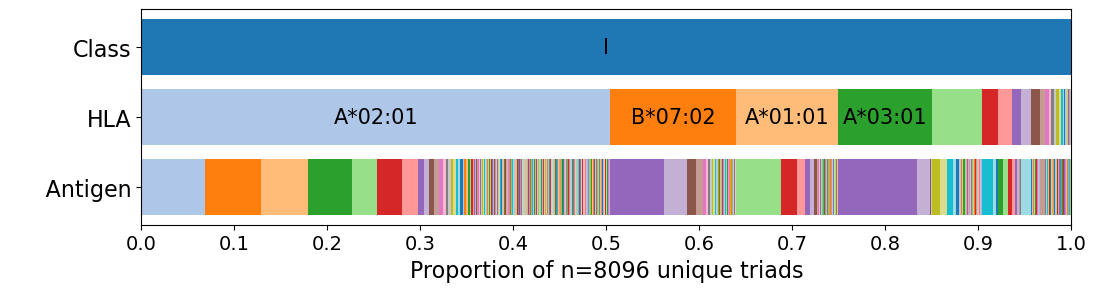

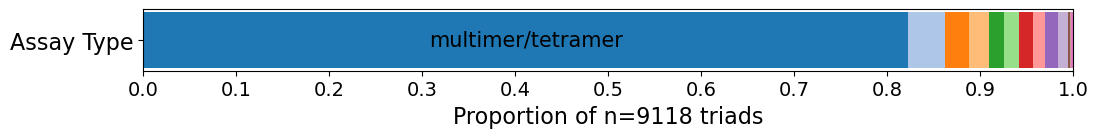

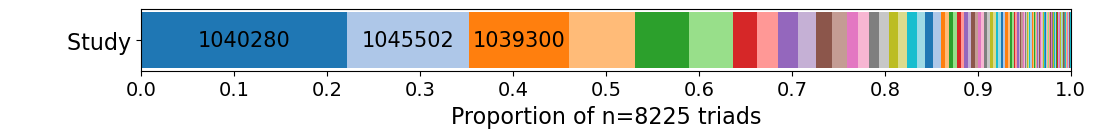

In [3]:
mhc_len = iedb_I.group_by(pl.col("mhc_1_name")).agg(pl.len())
pmhc_len = iedb_I.group_by(pl.col("mhc_1_name"), pl.col("peptide")).agg(
    pl.len().alias("pmhc_len")
)
iedb_I_len = (
    iedb_I.join(mhc_len, on="mhc_1_name")
    .join(pmhc_len, on=["mhc_1_name", "peptide"])
    .sort(by=["len", "mhc_1_name", "pmhc_len"], descending=True)
)

mhc_class = iedb_I_len.select("mhc_class").to_series().to_list()
hla_allele = iedb_I_len.select(pl.col("mhc_1_name")).to_series().to_list()
antigen = (
    iedb_I_len.select(pl.concat_str(["mhc_1_name", "peptide"])).to_series().to_list()
)

iedb_I_expl = iedb_I.explode("references").explode("references")
study_len = iedb_I_expl.group_by(pl.col("references")).agg(pl.len())
iedb_I_sl = iedb_I_expl.join(study_len, on="references").sort(
    by=["len", "references"], descending=True
)
study = iedb_I_sl.select("references").to_series().to_list()

at_len = iedb_I_at.group_by(pl.col("assay_type")).agg(pl.len())
iedb_I_al = iedb_I_at.join(at_len, on="assay_type").sort(
    by=["len", "assay_type"], descending=True
)
at = iedb_I_al.select("assay_type").to_series().to_list()


plot_stacked_category_proportions(
    ["Class", "HLA", "     Antigen"],
    [mhc_class, hla_allele, antigen],
    annotate=[True, True, False],
    unit="unique triads",
)

plot_stacked_category_proportions(["Assay Type"], [at], annotate=[True], unit="triads")


plot_stacked_category_proportions(
    ["        Study"], [study], annotate=[True], unit="triads"
)

d = pl.DataFrame({"antigen": antigen})
s = d.group_by("antigen").len().sort(by="len", descending=True)["len"].to_numpy()
print(
    "Dominant proportion: "
    + str(s[:11].sum() / iedb_I.select("job_name").unique().height)
)
print("Num antigens: " + str(d.select("antigen").unique().height))
print(
    "Proportion of total num antigens: "
    + str((11 / d.select("antigen").unique().height) * 100)
)
# np.array(study[:4]) / 8225


d = pl.DataFrame({"study": study})
s = d.group_by("study").len().sort(by="len", descending=True)["len"].to_numpy()
print("Dominant proportion: " + str(s[:4].sum() / study_len.select("len").sum().item()))
print("Num unique studies: " + str(d.select("study").unique().height))
print(
    "Proportion of unique studies represented by top 4 studies: "
    + str(4 / d.select("study").unique().height * 100)
)

Dominant proportion: 0.5347721822541966
Num antigens: 279
Proportion of total num antigens: 1.0752688172043012
Dominant proportion: 0.5125148986889154
Num unique studies: 62
Proportion of unique studies represented by top 2 studies: 3.225806451612903


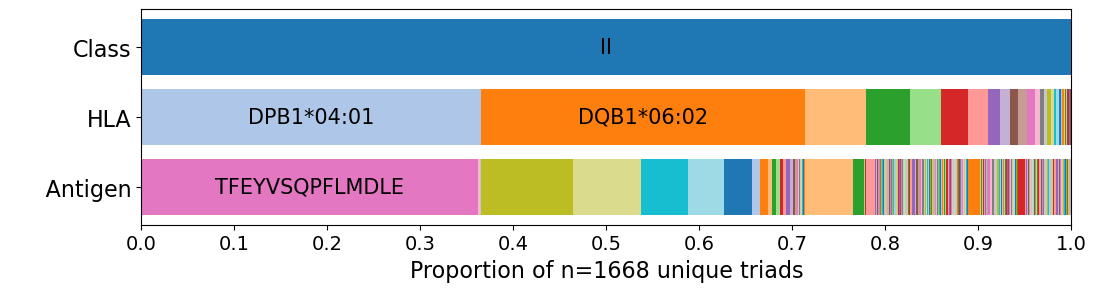

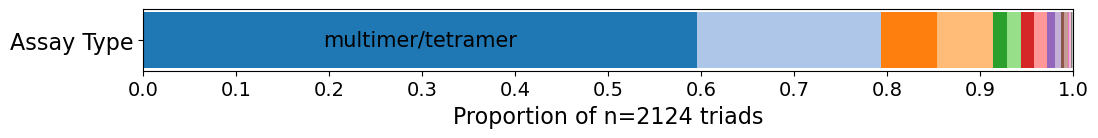

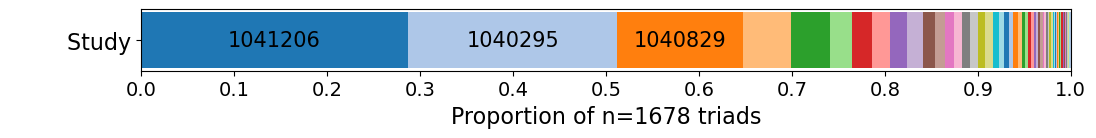

In [4]:
mhc_len = iedb_II.group_by(pl.col("mhc_2_name")).agg(pl.len())
pmhc_len = iedb_II.group_by(pl.col("mhc_2_name"), pl.col("peptide")).agg(
    pl.len().alias("pmhc_len")
)
iedb_II_len = (
    iedb_II.join(mhc_len, on="mhc_2_name")
    .join(pmhc_len, on=["mhc_2_name", "peptide"])
    .sort(by=["len", "mhc_2_name", "pmhc_len"], descending=True)
)
mhc_class = iedb_II_len.select("mhc_class").to_series().to_list()
hla_allele = (
    iedb_II_len.select(pl.col("mhc_2_name").str.slice(0, 10)).to_series().to_list()
)
antigen = (
    iedb_II_len.select(pl.concat_str(["mhc_2_name", pl.lit("-"), "peptide"]))
    .to_series()
    .to_list()
)


iedb_II_expl = iedb_II.explode("references").explode("references")
study_len = iedb_II_expl.group_by(pl.col("references")).agg(pl.len())
iedb_II_sl = iedb_II_expl.join(study_len, on="references").sort(
    by=["len", "references"], descending=True
)
study = iedb_II_sl.select("references").to_series().to_list()


at_len = iedb_II_at.group_by(pl.col("assay_type")).agg(pl.len())
iedb_II_al = iedb_II_at.join(at_len, on="assay_type").sort(
    by=["len", "assay_type"], descending=True
)
at = iedb_II_al.select("assay_type").to_series().to_list()

plot_stacked_category_proportions(
    ["Class", "HLA", "     Antigen"],
    [mhc_class, hla_allele, antigen],
    annotate=[True, True, True],
    unit="unique triads",
)

plot_stacked_category_proportions(["Assay Type"], [at], annotate=[True], unit="triads")


plot_stacked_category_proportions(
    ["        Study"], [study], annotate=[True], unit="triads"
)

d = pl.DataFrame({"antigen": antigen})
s = d.group_by("antigen").len().sort(by="len", descending=True)["len"].to_numpy()
print(
    "Dominant proportion: "
    + str(s[:3].sum() / iedb_II.select("job_name").unique().height)
)
print("Num antigens: " + str(d.select("antigen").unique().height))
print(
    "Proportion of total num antigens: "
    + str((3 / d.select("antigen").unique().height) * 100)
)
# print(s[:3].sum() / 1668)
# print(d.select("antigen").unique().height)
# print(6 / d.select("antigen").unique().height)

d = pl.DataFrame({"study": study})
s = d.group_by("study").len().sort(by="len", descending=True)["len"].to_numpy()
print("Dominant proportion: " + str(s[:2].sum() / study_len.select("len").sum().item()))
print("Num unique studies: " + str(d.select("study").unique().height))
print(
    "Proportion of unique studies represented by top 2 studies: "
    + str(2 / d.select("study").unique().height * 100)
)